# MuJoCo under the hood: Hopper

Direct experiments against the C bindings (`mj_step`, `mj_forward`, ...) using the gymnasium Hopper XML. Each cell is independent — run them in order or skip around.

In [1]:
import time
import numpy as np
import mujoco as mj

XML = ("/Users/ljn/cd_project/.pixi/envs/default/lib/python3.12/"
       "site-packages/gymnasium/envs/mujoco/assets/hopper.xml")

m = mj.MjModel.from_xml_path(XML)
d = mj.MjData(m)

print(f"nq={m.nq}  nv={m.nv}  nu={m.nu}  nbody={m.nbody}  ngeom={m.ngeom}")
print(f"timestep={m.opt.timestep}  integrator={m.opt.integrator}")

nq=6  nv=6  nu=3  nbody=5  ngeom=5
timestep=0.002  integrator=1


In [184]:
import inspect

In [195]:
d.qpos

array([0.  , 1.25, 0.  , 0.  , 0.  , 0.  ])

In [ ]:
d.qpos = np.random.randn(1000, 6)
mj.mj_forward(m, d)
d.qacc

ValueError: could not broadcast input array from shape (1000,6) into shape (6,)

## 1. Plain `mj_step`
Identical to what `env.step()` does under the hood.

In [147]:
d.ctrl[:] = np.array([0.1, -0.2, 0.05])
mj.mj_step(m, d)
print("after 1 step: qpos =", d.qpos)

after 1 step: qpos = [-5.59473410e-04  1.24806679e+00 -2.76167863e-03  3.81288164e-04
 -6.77649119e-03  2.15924068e-03]


## 2. `mj_forward`: forward dynamics without integrating
Computes `qacc` from current `(qpos, qvel, ctrl)` but doesn't advance time.

In [193]:
mj.mj_resetData(m, d)
d.ctrl[:] = 0.1
mj.mj_forward(m, d)
print("qacc (no integration) =", d.qacc)
print("qfrc_actuator        =", d.qfrc_actuator)
print("qfrc_bias (Coriolis+gravity) =", d.qfrc_bias)

qacc (no integration) = [  2.59623133 -10.38923145  21.35145622  16.61836142  14.39549358
  16.85893703]
qfrc_actuator        = [ 0.  0.  0. 20. 20. 20.]
qfrc_bias (Coriolis+gravity) = [  0.         155.19433151  -3.38947625   3.38947625   3.38947625
   3.38947625]


## 3. `mj_step1` / `mj_step2` split
Set `ctrl` *after* the position- and velocity-dependent quantities are already computed. Useful when your controller depends on `qvel` or sensor readouts you don't want to recompute.

In [150]:
mj.mj_resetData(m, d)
mj.mj_step1(m, d)                # everything that doesn't need ctrl
my_ctrl = -0.3 * d.qvel[3:]      # tiny joint-velocity feedback controller
d.ctrl[:] = my_ctrl
mj.mj_step2(m, d)                # actuation + integration
print("qpos =", d.qpos)
print("qvel =", d.qvel)

qpos = [ 5.39283403e-22  1.24996076e+00  2.22044605e-21  1.55431223e-21
  8.88178420e-22 -1.77635684e-21]
qvel = [ 2.69641702e-19 -1.96200000e-02  1.11022302e-18  7.77156117e-19
  4.44089210e-19 -8.88178420e-19]


## 4. Pipeline pieces individually + contacts
`mj_fwdPosition` runs kinematics, mass matrix, and collision detection — but no forces yet.

In [151]:
mj.mj_resetData(m, d)
mj.mj_fwdPosition(m, d)
print("qM (mass matrix, sparse) shape =", d.qM.shape)
print("# contacts after position phase =", d.ncon)
for i in range(d.ncon):
    c = d.contact[i]
    print(f"  contact {i}: geoms ({c.geom1}, {c.geom2})  dist={c.dist:.5f}")

qM (mass matrix, sparse) shape = (21,)
# contacts after position phase = 0


## 5. Swap integrator, time a 1-second rollout
RK4 is the default in the Hopper XML. Euler is fastest. Implicit is more stable at high damping.

In [ ]:
for name, code in [("RK4", mj.mjtIntegrator.mjINT_RK4),
                   ("Euler", mj.mjtIntegrator.mjINT_EULER),
                   ("implicit", mj.mjtIntegrator.mjINT_IMPLICIT)]:
    m.opt.integrator = code
    mj.mj_resetData(m, d)
    n = int(1.0 / m.opt.timestep)
    rng = np.random.default_rng(0)
    t0 = time.perf_counter()
    for _ in range(n):
        d.ctrl[:] = rng.uniform(-0.4, 0.4, size=m.nu)
        mj.mj_step(m, d)
    print(f"{name:>8}: {n} steps in {1e3*(time.perf_counter()-t0):.1f} ms, "
          f"final z = {d.qpos[1]:.3f}")

## 6. Domain randomization
Same fields used in `src/data/generation/mujoco.py`. After mutating, call `mj_forward` to refresh derived quantities (mass matrix, etc.).

In [168]:
mj.mj_resetData(m, d)
m.body_mass[:] *= 1.5
m.dof_damping[:] *= 2.0
m.geom_friction[:] *= 0.5
mj.mj_forward(m, d)
print("scaled body_mass =", m.body_mass)

scaled body_mass = [   0.         3611.17110131 3998.08229074 2740.36298431 5237.22986008]


## 7. Midphase BVH on/off
For the Hopper the difference is small (few geoms) — try it on Ant or Humanoid to see the BVH earn its keep.

In [171]:
m = mj.MjModel.from_xml_path(XML)  # fresh model — clears domain rand from prev cell
d = mj.MjData(m)
for label, flag in [("midphase on", 0),
                    ("midphase off", mj.mjtDisableBit.mjDSBL_MIDPHASE)]:
    m.opt.disableflags = flag
    mj.mj_resetData(m, d)
    t0 = time.perf_counter()
    for _ in range(1000):
        mj.mj_step(m, d)
    print(f"{label}: 1000 steps in {1e3*(time.perf_counter()-t0):.1f} ms")

midphase on: 1000 steps in 21.7 ms
midphase off: 1000 steps in 17.6 ms


## 8. Exercise: drop the hopper and watch contacts appear
Zero `ctrl`, lift to z=2.0, step until it lands. Contact count should spike from 0 to 2-3 at impact.

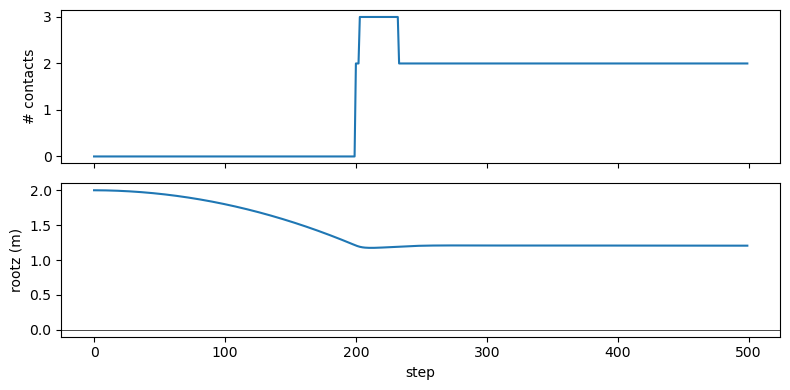

In [174]:
mj.mj_resetData(m, d)
d.qpos[1] = 2.0          # rootz: lift hopper to 2m
d.ctrl[:] = 0.0
ncon_history = []
for step in range(500):
    mj.mj_step(m, d)
    ncon_history.append(d.ncon)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
axes[0].plot(ncon_history)
axes[0].set_ylabel("# contacts")
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylabel("rootz (m)")
axes[1].set_xlabel("step")
# replay to record qpos
mj.mj_resetData(m, d); d.qpos[1] = 2.0
z = []
for _ in range(500):
    mj.mj_step(m, d); z.append(d.qpos[1])
axes[1].plot(z)
plt.tight_layout(); plt.show()